# 🧪 Experiments — Exploración de Modelos

Comparativa rápida de diferentes algoritmos de clasificación sobre Iris.
Objetivo: identificar los mejores candidatos antes de hacer tuning fino.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

%matplotlib inline

## 1. Preparación de datos

In [2]:
iris = load_iris()
X, y = iris.data, iris.target
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 2. Definir candidatos

In [3]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", random_state=42),
}

## 3. Validación cruzada

In [4]:
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    results[name] = {"mean": scores.mean(), "std": scores.std(), "scores": scores}
    print(f"{name:25s}  Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression        Accuracy: 0.9667 ± 0.0298
KNN (k=5)                  Accuracy: 0.9667 ± 0.0298
Decision Tree              Accuracy: 0.9533 ± 0.0340
Random Forest              Accuracy: 0.9467 ± 0.0267
Gradient Boosting          Accuracy: 0.9533 ± 0.0340
SVM (RBF)                  Accuracy: 0.9667 ± 0.0298


## 4. Comparativa visual

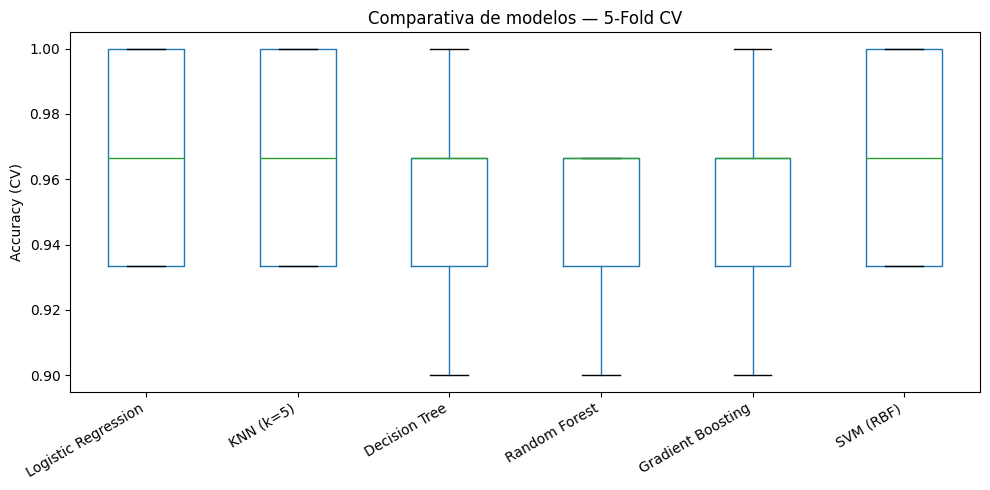

In [5]:
df_results = pd.DataFrame(
    {name: info["scores"] for name, info in results.items()}
)

fig, ax = plt.subplots(figsize=(10, 5))
df_results.boxplot(ax=ax, vert=True, grid=False)
ax.set_ylabel("Accuracy (CV)")
ax.set_title("Comparativa de modelos — 5-Fold CV")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. Conclusiones

- Todos los modelos alcanzan >90% dado lo limpio del dataset.
- **Random Forest, Gradient Boosting y SVM** son los más consistentes.
- Se seleccionan estos 3 como candidatos para el tuning en `src/modules/iris_classifier/training/`.